#Implementing a VAE

In [2]:
import torch
from torch.distributions.multivariate_normal \
  import MultivariateNormal
import torch.nn as nn
from torchvision import datasets, transforms
from torchvision.utils import save_image
import torch.optim as optim

In [6]:
# For reproducability
import random
random.seed(0)

torch.manual_seed(0)

In [3]:
# Encoder layers (Gaussian MLP)
D_in, H, D_out = 784, 200, 2
input_layer = nn.Linear(D_in, H)
hidden_layer_mean = nn.Linear(H, D_out)
hidden_layer_var = nn.Linear(H, D_out)

In [4]:
# Decoder layers (Bernoulli MLP for MNIST data)
recon_layer = nn.Linear(D_out, H)
recon_output = nn.Linear(H, D_in)

In [12]:
import numpy as np
class VAE(nn.Module):
  def __init__(self, D_in, H, D_out):
    super(VAE, self).__init__()
    self.D_in, self.H, self.D_out = D_in, H, D_out

    # Encoder layers (Gaussian MLP)
    self.input_layer = nn.Linear(D_in, H)
    self.hidden_layer_mean = nn.Linear(H, D_out)
    self.hidden_layer_var = nn.Linear(H, D_out)

    # Decoder layers (Bernoulli MLP for MNIST data)
    self.recon_layer = nn.Linear(D_out, H)
    self.recon_output = nn.Linear(H, D_in)
    self.tanh = nn.Tanh()
    self.sigmoid = nn.Sigmoid()

  def encode(self, inp):
    h_vec = self.input_layer(inp)
    h_vec = self.sigmoid(h_vec)
    means = self.hidden_layer_mean(h_vec)
    log_vars = self.hidden_layer_var(h_vec)
    return means, log_vars

  def decode(self, means, log_vars):
    # Reparametrization trick
    std_devs = torch.exp(0.5 * log_vars)
    aux = torch.randn_like(means)
    sample = means + aux * std_devs
    return self.reconstruct(sample)


  def forward(self, inp):
    means, log_vars = self.encode(inp)
    output = self.decode(means, log_vars)
    return output, means, log_vars

  def reconstruct(self, sample):
    h_vec = self.recon_layer(sample)
    h_vec = self.tanh(h_vec)
    output = self.sigmoid(self.recon_output(h_vec))
    return output

In [4]:
def compute_loss(inp, recon_inp, means, log_vars):
  # Calculate reverse KL divergence
  # (formula provided in Kingma and Welling)
  kl_loss = -0.5 * torch.sum(1 + log_vars
                            - means ** 2 - torch.pow(2,log_vars))

  # Calculate BCE loss
  loss = nn.BCELoss(reduction="sum")
  recon_loss = loss(recon_inp, inp)
  return kl_loss + recon_loss

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [15]:
D_in, H, D_out = 784, 500, 2
vae = VAE(D_in, H, D_out)
vae.to(device)

def train():
  vae.train()
  optimizer = optim.Adam(vae.parameters(), lr=1e-3)

  train_loader = torch.utils.data.DataLoader(
      datasets.MNIST('../data',
                     train=True,
                     download=True,
                     transform=transforms.ToTensor()),
                     batch_size=100,
                     shuffle=True)

  epochs = 10
  for epoch in range(epochs):
    for batch_idx, (data, _) in enumerate(train_loader):
      optimizer.zero_grad()
      data = data.view((100,784)).to(device)
      output, means, log_vars = vae(data)
      loss = compute_loss(data, output, means, log_vars)
      loss.backward()
      optimizer.step()
      if (batch_idx * len(data)) % 10000 == 0:
        print(
            'Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}' \
            .format(
            epoch, batch_idx * len(data), len(train_loader.dataset),
            100. * batch_idx / len(train_loader), loss.item()))
  torch.save(vae.state_dict(), "vae.%d" % epoch)

In [16]:
def test():
    dist = MultivariateNormal(torch.zeros(D_out), torch.eye(D_out))
    vae_eval = VAE(D_in, H, D_out).to(device)
    vae_eval.load_state_dict(torch.load("vae.9", map_location=device))
    vae_eval.eval()

    with torch.no_grad():
        samples = dist.sample((100,)).to(device)   # <-- sample all 100 at once, move to GPU
        outputs = vae_eval.reconstruct(samples).view(100, 1, 28, 28)
        outputs = outputs.cpu()   # <-- move back to CPU before saving image
        save_image(outputs, "prior_reconstruct_100.png", nrow=10)



In [17]:
train()

Train Epoch: 0 [0/60000 (0%)]	Loss: 55676.378906
Train Epoch: 0 [10000/60000 (17%)]	Loss: 18828.246094
Train Epoch: 0 [20000/60000 (33%)]	Loss: 17899.052734
Train Epoch: 0 [30000/60000 (50%)]	Loss: 17726.041016
Train Epoch: 0 [40000/60000 (67%)]	Loss: 18210.033203
Train Epoch: 0 [50000/60000 (83%)]	Loss: 17686.955078
Train Epoch: 1 [0/60000 (0%)]	Loss: 16778.664062
Train Epoch: 1 [10000/60000 (17%)]	Loss: 17081.951172
Train Epoch: 1 [20000/60000 (33%)]	Loss: 18240.865234
Train Epoch: 1 [30000/60000 (50%)]	Loss: 18572.285156
Train Epoch: 1 [40000/60000 (67%)]	Loss: 16459.298828
Train Epoch: 1 [50000/60000 (83%)]	Loss: 16724.470703
Train Epoch: 2 [0/60000 (0%)]	Loss: 16201.080078
Train Epoch: 2 [10000/60000 (17%)]	Loss: 16783.833984
Train Epoch: 2 [20000/60000 (33%)]	Loss: 16583.050781
Train Epoch: 2 [30000/60000 (50%)]	Loss: 17003.152344
Train Epoch: 2 [40000/60000 (67%)]	Loss: 16651.089844
Train Epoch: 2 [50000/60000 (83%)]	Loss: 15813.619141
Train Epoch: 3 [0/60000 (0%)]	Loss: 16371.9

In [18]:
test()

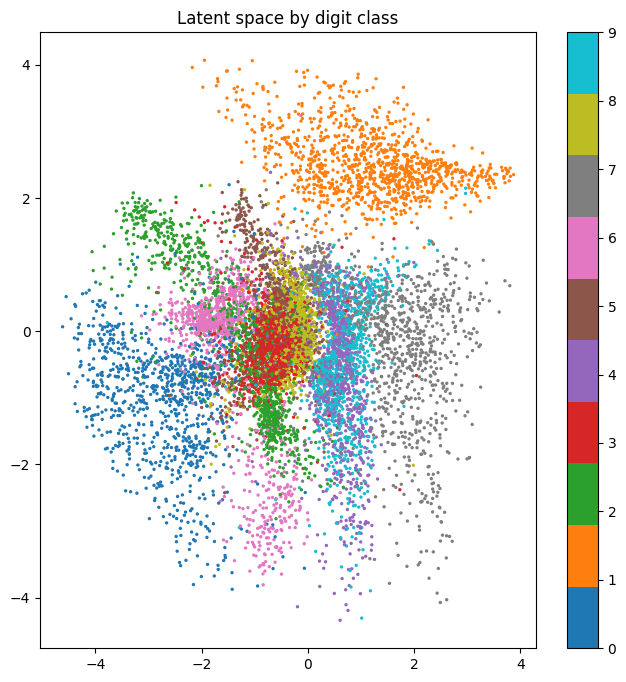

In [19]:
import matplotlib.pyplot as plt

test_loader = torch.utils.data.DataLoader(
    datasets.MNIST('../data', train=False, download=True,
                   transform=transforms.ToTensor()),
    batch_size=1000, shuffle=False)

vae.eval()
all_means, all_labels = [], []
with torch.no_grad():
    for data, labels in test_loader:
        data = data.view(data.size(0), 784).to(device)
        means, _ = vae.encode(data)
        all_means.append(means.cpu())
        all_labels.append(labels)

all_means = torch.cat(all_means).numpy()
all_labels = torch.cat(all_labels).numpy()

plt.figure(figsize=(8,8))
plt.scatter(all_means[:,0], all_means[:,1], c=all_labels, cmap='tab10', s=2)
plt.colorbar()
plt.title("Latent space by digit class")
plt.show()